In [1]:
from __future__ import print_function

import numpy as np
from matplotlib import pyplot as plt
from scipy import stats, interpolate
from astropy.visualization import hist
from astroML.density_estimation import EmpiricalDistribution

(array([  4.,  16.,  36.,  45.,  79., 147., 151., 162., 154., 176., 207.,
        177., 200., 201., 186., 182., 219., 265., 249., 224., 265., 293.,
        303., 305., 296., 261., 284., 332., 298., 304., 277., 284., 265.,
        286., 211., 168., 203., 182., 189., 170., 158., 128., 114., 125.,
         98., 111.,  86.,  78.,  75.,  82.,  75.,  56.,  56.,  48.,  38.,
         41.,  36.,  31.,  34.,  29.,  25.,  20.,  12.,  13.,  13.,   9.,
         17.,  15.,  18.,  10.,   8.,   1.,  17.,   6.,   9.,   3.,  13.,
          7.,   3.,   5.,   0.,   1.,   4.,   1.,   1.,   1.,   0.,   5.,
          0.,   1.,   0.,   2.,   3.,   1.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.0802    , 0.133533  , 0.186866  , 0.240199  , 0.29353198,
        0.346865  , 0.40019798, 0.453531  , 0.506864  , 0.560197  ,
        0.61353   , 0.66686296, 0.720196  , 0.773529  , 0.826862  ,
        0.88019496, 0.93352795, 0.986861  , 1.0401939 , 1.093527  ,
        1.14686   , 1.2001929 , 1.253526  , 1.

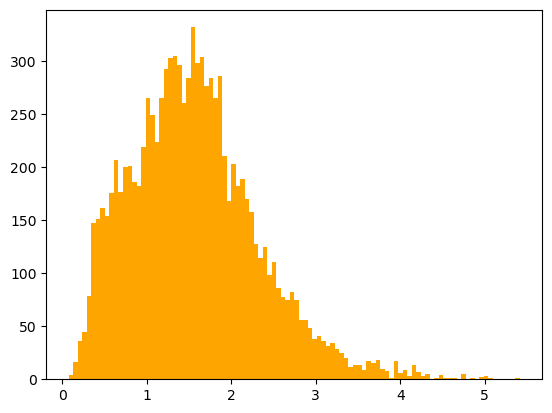

In [2]:
from astroML.datasets import fetch_dr7_quasar

# Fetch the quasar data
data = fetch_dr7_quasar()

# select the first 10000 points
data = data[:10000]

z = data['redshift']

N_bin = 100
hist , bin_edges = np.histogram(z,N_bin)
max(hist)
plt.hist(z,bins = N_bin, color = 'orange')

In [3]:
#RESAMPLING
#genero dati distribuiti randomicamente e li binno
size_sample = 100000
x_unif = np.random.uniform(low=0.0, high=np.max(z), size=size_sample)
y_unif = np.random.uniform(low=0.0, high=max(hist), size=size_sample)
hist2, bin_edges2 = np.histogram(x_unif , N_bin)

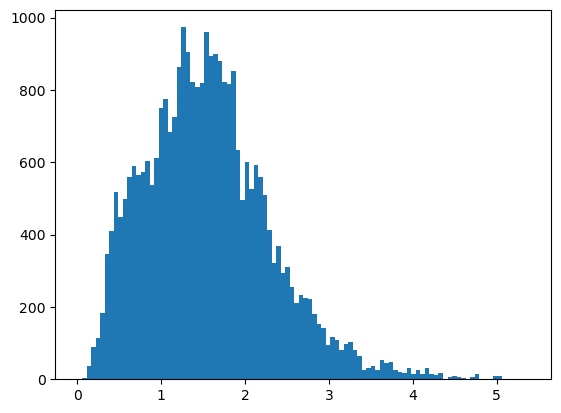

In [4]:
#applico il controllo del resampling controllando che i dati generati
#vengano accettati solo se la loro y è minore dell'altezza del bin di cui fanno parte
gen_data = np.array([])
for i in range (size_sample):
    bin_index = np.digitize(x_unif[i], bin_edges) - 1
    if (y_unif[i] < hist[bin_index]): 
        gen_data = np.append(gen_data,x_unif[i])
        
plt.hist(gen_data, bins=N_bin)   
plt.show()

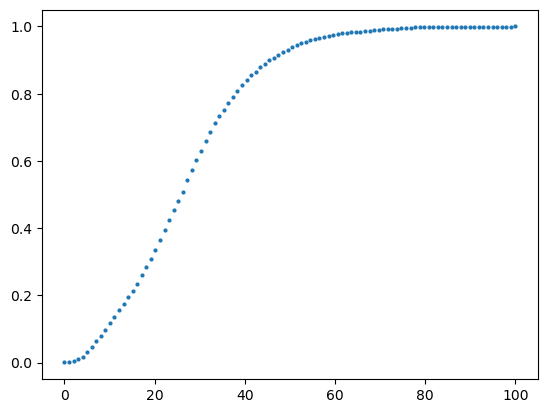

In [5]:
#INVERSE SAMPLING
#calcolo la mia funzione cumulativa e il suo inverso 
#(siccome sto lavorando con un istogramma, mi basta definire un array con al suo interno il volume
#di ogni Bin e l'array del suo inverso)

#calcolo volume Bin
V = np.array([])
C = np.array([])
Sum = 0
l = np.linspace(0,N_bin, N_bin)
for i in range (N_bin):
    V = np.append(V,(bin_edges[i+1]-bin_edges[i])*hist[i])

#calcolo integrale funzione binnata
for i in range (N_bin):
    Sum += V[i]
    C = np.append(C,Sum)
    
Norm_C = C/C[N_bin-1]
plt.scatter(l,Norm_C, s=4)
plt.show()

(array([1.570e+02, 3.570e+02, 4.480e+02, 7.590e+02, 1.405e+03, 1.488e+03,
        1.599e+03, 1.549e+03, 1.689e+03, 1.995e+03, 1.798e+03, 1.922e+03,
        1.997e+03, 1.840e+03, 1.836e+03, 2.067e+03, 2.535e+03, 2.486e+03,
        2.244e+03, 2.534e+03, 2.763e+03, 3.040e+03, 2.960e+03, 2.959e+03,
        2.664e+03, 2.763e+03, 3.058e+03, 3.054e+03, 3.032e+03, 2.821e+03,
        2.790e+03, 2.749e+03, 2.659e+03, 2.420e+03, 1.853e+03, 1.870e+03,
        1.850e+03, 1.833e+03, 1.761e+03, 1.656e+03, 1.408e+03, 1.215e+03,
        1.165e+03, 1.113e+03, 1.012e+03, 9.970e+02, 8.380e+02, 7.660e+02,
        7.420e+02, 8.020e+02, 6.790e+02, 5.310e+02, 5.530e+02, 4.350e+02,
        3.940e+02, 3.830e+02, 3.530e+02, 3.180e+02, 3.180e+02, 2.910e+02,
        2.150e+02, 1.890e+02, 1.190e+02, 1.290e+02, 1.280e+02, 9.700e+01,
        1.680e+02, 1.530e+02, 1.650e+02, 1.000e+02, 7.400e+01, 1.600e+01,
        1.640e+02, 6.000e+01, 9.000e+01, 3.000e+01, 1.270e+02, 6.800e+01,
        3.400e+01, 4.900e+01, 2.000e+0

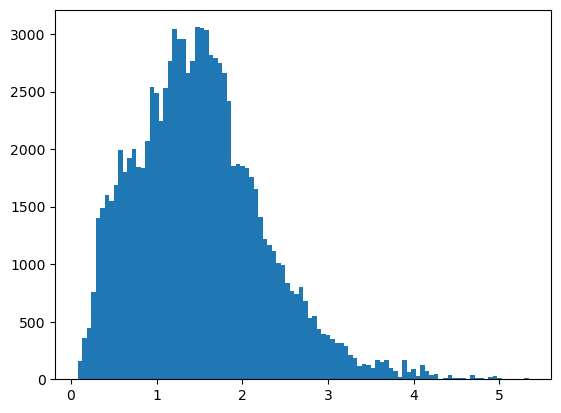

In [6]:
#INVERSE
N_samples = 100000
Prob = np.linspace(0,1,N_samples)
x_gen = np.array([])
for i in range (N_samples):
    for j in range (N_bin-1):
        if (Prob[i] < Norm_C[j+1] and Prob[i] > Norm_C[j]):
            x_gen = np.append(x_gen, np.random.uniform(low=bin_edges[j], high=bin_edges[j+1], size=1))
            
plt.hist(x_gen, bins = N_bin)